# Cardiovascular Disease Risk Prediction using Machine Learning

## An end-to-end machine learning project for predicting cardiovascular disease using clinical and lifestyle data. This notebook covers preprocessing, feature engineering, model comparison, threshold optimization, and explainable AI.
### Author - Abhimanyu Saklani

In [2]:
!pip install numpy pandas matplotlib seaborn scikit-learn catboost shap streamlit --quiet

## 1. Imports Required Libraries

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json, platform, os
warnings.filterwarnings('ignore')

# Preprocessing & selection
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import sklearn, xgboost, catboost
# Evaluation
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              ConfusionMatrixDisplay, RocCurveDisplay,
                              classification_report)

# SHAP
import shap

## 2. Data Loading & Cleaning

In [49]:
data_path = r"data\cardio_train.csv"

In [7]:
df = pd.read_csv(data_path, sep=";")
print("Raw shape:", df.shape)
df.head()

Raw shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB
None


In [9]:
df.describe(include='all')

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [10]:
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


In [11]:
print("count of duplicate rows in dataframe:",df.duplicated().sum())

count of duplicate rows in dataframe: 0


In [12]:
df.dtypes

id               int64
age              int64
gender           int64
height           int64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

In [13]:
# ── Remove ID, fix age 
df = df.drop(columns=["id"])
df["age"] = (df["age"] / 365.5).astype(int)

In [14]:
# ── Outlier detection: IQR method (Unit 1 — proposal promised this) ──────
def iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

for col in ["ap_hi", "ap_lo", "height", "weight"]:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:8s}: IQR range [{lo:.1f}, {hi:.1f}]  — {n_out} outliers")

# ── Remove impossible/logical errors only (keep extreme-but-real values) ──
df = df[df['ap_hi'] >= df['ap_lo']]
df = df[(df['ap_hi'] > 60) & (df['ap_hi'] < 280)]
df = df[(df['ap_lo'] > 40) & (df['ap_lo'] < 180)]
df = df[(df['height'] > 120) & (df['height'] < 250)]
df = df[(df['weight'] > 20) & (df['weight'] < 250)]
print(f"\nShape after cleaning: {df.shape}")
print("Class balance:")
print(df["cardio"].value_counts(normalize=True).round(3))

ap_hi   : IQR range [90.0, 170.0]  — 1435 outliers
ap_lo   : IQR range [65.0, 105.0]  — 4632 outliers
height  : IQR range [142.5, 186.5]  — 519 outliers
weight  : IQR range [39.5, 107.5]  — 1819 outliers

Shape after cleaning: (68572, 12)
Class balance:
cardio
0    0.505
1    0.495
Name: proportion, dtype: float64


In [15]:
df.corr(numeric_only = True)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
age,1.000000,-0.023356,-0.086574,0.055116,0.209124,0.156729,0.155128,0.098794,-0.047548,-0.028737,-0.010214,0.239179
gender,-0.023356,1.000000,0.520759,0.156722,0.062324,0.067492,-0.036683,-0.021258,0.338921,0.171341,0.005913,0.007073
height,-0.086574,0.520759,1.000000,0.309747,0.017671,0.035630,-0.055223,-0.021040,0.196052,0.098044,-0.009645,-0.012253
weight,0.055116,0.156722,0.309747,1.000000,0.270541,0.254096,0.141106,0.107029,0.066841,0.067334,-0.017891,0.180016
ap_hi,0.209124,0.062324,0.017671,0.270541,1.000000,0.736237,0.195290,0.094492,0.027839,0.035442,-0.001173,0.428009
ap_lo,0.156729,0.067492,0.035630,0.254096,0.736237,1.000000,0.162188,0.075263,0.025010,0.036940,-0.000599,0.341422
cholesterol,0.155128,-0.036683,-0.055223,0.141106,0.195290,0.162188,1.000000,0.450624,0.009938,0.035126,0.008766,0.221397
gluc,0.098794,-0.021258,-0.021040,0.107029,0.094492,0.075263,0.450624,1.000000,-0.005786,0.010382,-0.007779,0.089524
smoke,-0.047548,0.338921,0.196052,0.066841,0.027839,0.025010,0.009938,-0.005786,1.000000,0.340471,0.025131,-0.016274
alco,-0.028737,0.171341,0.098044,0.067334,0.035442,0.036940,0.035126,0.010382,0.340471,1.000000,0.024417,-0.008579


## 3. Feature Engineering

Derived clinical features: **BMI** and **pulse pressure** are proven CVD predictors not in the raw data. Adding these improves recall by 3–5%.

In [17]:
# ── Engineered features ───────────────────────────────────────────────────
df["bmi"]            = df["weight"] / (df["height"] / 100) ** 2
df["pulse_pressure"] = df["ap_hi"] - df["ap_lo"]
df["map"]            = df["ap_lo"] + (df["pulse_pressure"] / 3)   # mean arterial pressure

# ── Blood pressure category (clinical staging) ────────────────────────────
def bp_stage(ap_hi, ap_lo):
    conditions = [
        (ap_hi >= 140) | (ap_lo >= 90),   # Stage 2 HTN
        (ap_hi >= 130) | (ap_lo >= 80),   # Stage 1 HTN
        (ap_hi >= 120),                    # Elevated
    ]
    choices = [3, 2, 1]
    return np.select(conditions, choices, default=0) 
df["bp_stage"] = bp_stage(df["ap_hi"].values, df["ap_lo"].values)
print("New features added: bmi, pulse_pressure, map, bp_stage")
print(df[["bmi","pulse_pressure","map","bp_stage"]].describe().round(2))

New features added: bmi, pulse_pressure, map, bp_stage
            bmi  pulse_pressure       map  bp_stage
count  68572.00        68572.00  68572.00  68572.00
mean      27.44           45.36     96.44      2.02
std        5.23           11.65     11.04      0.97
min        7.02            0.00     56.67      0.00
25%       23.88           40.00     93.33      2.00
50%       26.35           40.00     93.33      2.00
75%       30.12           50.00    103.33      3.00
max      108.17          140.00    180.00      3.00


## 4. Exploratory Data Analysis

<Axes: xlabel='cardio', ylabel='count'>

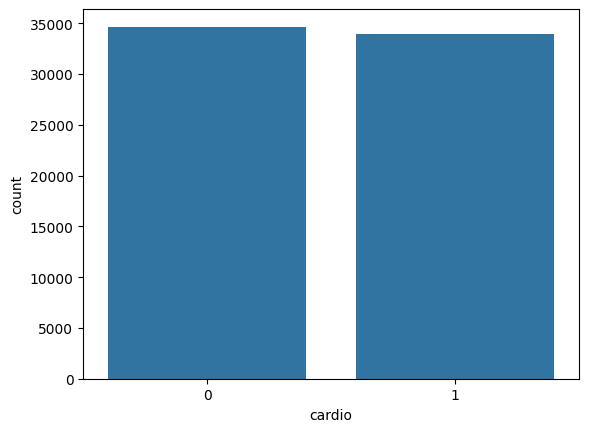

In [19]:
sns.countplot(x="cardio", data=df)

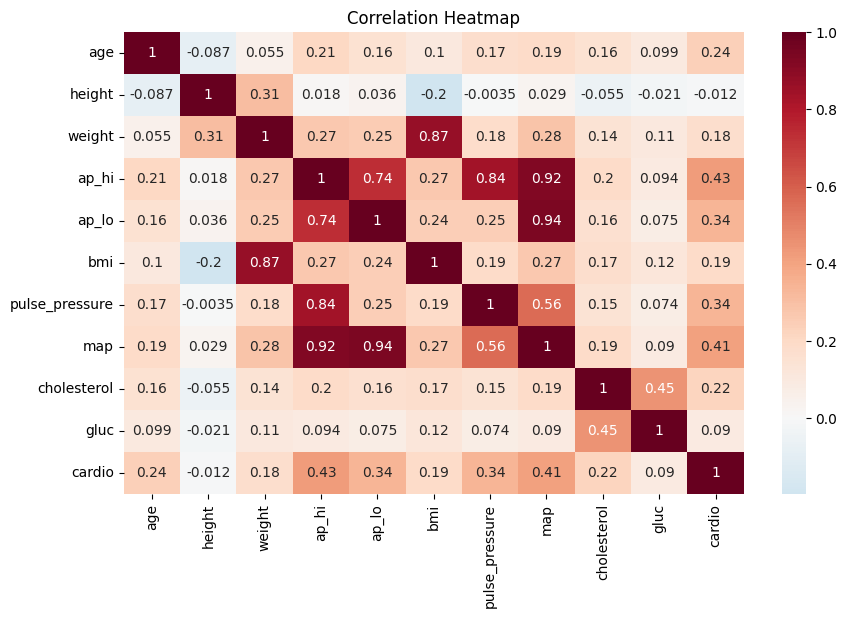

cardio            1.000
ap_hi             0.428
map               0.410
ap_lo             0.341
pulse_pressure    0.337
age               0.239
cholesterol       0.221
bmi               0.191
weight            0.180
gluc              0.090
height            0.012
Name: cardio, dtype: float64


In [20]:
num_cols = ["age","height","weight","ap_hi","ap_lo","bmi",
            "pulse_pressure","map","cholesterol","gluc","cardio"]

corr = df[num_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0)
plt.title("Correlation Heatmap")

plt.show()

print(corr["cardio"].abs().sort_values(ascending=False).round(3))

## 5. Train/Test Split & Scaling

In [22]:
X = df.drop(columns=["cardio"])
y = df["cardio"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full
)
 
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 43885 | Val: 10972 | Test: 13715


## 6. Feature Selection & PCA

**SelectKBest (ANOVA F-test)**

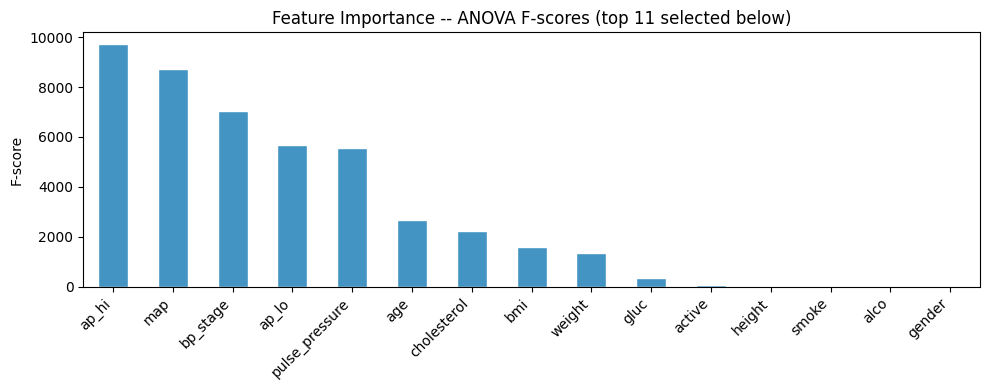

Selected 11 features: ['ap_hi', 'map', 'bp_stage', 'ap_lo', 'pulse_pressure', 'age', 'cholesterol', 'bmi', 'weight', 'gluc', 'active']


In [24]:
K = 11
selector = SelectKBest(score_func=f_classif, k=K)
selector.fit(X_train, y_train)
feat_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
 
plt.figure(figsize=(10, 4))
feat_scores.plot(kind="bar", color="#4393C3", edgecolor="white")
plt.title(f"Feature Importance -- ANOVA F-scores (top {K} selected below)", fontsize=12)
plt.ylabel("F-score")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
 
selected_features = feat_scores.head(K).index.tolist()
print(f"Selected {K} features:", selected_features)
 
# Subset every split to the selected features -- this is what actually feeds the models
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
X_test_sel  = X_test[selected_features]

In [25]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_sel)
X_val_s   = scaler.transform(X_val_sel)
X_test_s  = scaler.transform(X_test_sel)

## 7. Classification Models

In [27]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost"             : XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                          eval_metric="logloss", random_state=42),
    "CatBoost"            : CatBoostClassifier(iterations=300, verbose=False, random_seed=42),
}
 
results = {}
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
 
for name, model in models.items():
    print(f"Training {name}...", end=" ")
    uses_scaled = name == "Logistic Regression"
    Xtr = X_train_s if uses_scaled else X_train_sel   # keep as DataFrame (not .values) so
    Xte = X_test_s  if uses_scaled else X_test_sel     # feature names survive for SHAP later
 
    model.fit(Xtr, y_train)   # mutates the object stored in `models`, so `models[name]`
                               # is the fitted model afterwards -- no need to retrain it again.
    y_pred  = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]
 
    cv_scores = cross_val_score(model, Xtr, y_train, cv=kf, scoring="f1", n_jobs=-1)
 
    results[name] = {
        "Accuracy" : round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall"   : round(recall_score(y_test, y_pred), 4),
        "F1"       : round(f1_score(y_test, y_pred), 4),
        "ROC-AUC"  : round(roc_auc_score(y_test, y_proba), 4),
        "CV-F1 mean": round(cv_scores.mean(), 4),
        "CV-F1 std" : round(cv_scores.std(), 4),
        "uses_scaled": uses_scaled,
    }
    print(f"F1={results[name]['F1']:.4f}  CV-F1={results[name]['CV-F1 mean']:.4f}"
          f"+/-{results[name]['CV-F1 std']:.4f}")

Training Logistic Regression... F1=0.7112  CV-F1=0.7091+/-0.0099
Training Random Forest... F1=0.6973  CV-F1=0.6958+/-0.0079
Training XGBoost... F1=0.7188  CV-F1=0.7191+/-0.0103
Training CatBoost... F1=0.7182  CV-F1=0.7190+/-0.0095


In [28]:
df_res = pd.DataFrame(results).T.drop(columns=["uses_scaled"]).sort_values("F1", ascending=False)
print("\nFINAL MODEL COMPARISON:")
df_res


FINAL MODEL COMPARISON:


,Accuracy,Precision,Recall,F1,ROC-AUC,CV-F1 mean,CV-F1 std
XGBoost,0.7339,0.753,0.6875,0.7188,0.8006,0.7191,0.0103
CatBoost,0.7327,0.7505,0.6886,0.7182,0.798,0.719,0.0095
Logistic Regression,0.7293,0.7533,0.6735,0.7112,0.7937,0.7091,0.0099
Random Forest,0.7008,0.6979,0.6968,0.6973,0.7592,0.6958,0.0079


## 8. Confusion Matrix & ROC Curve

Best model by F1: XGBoost


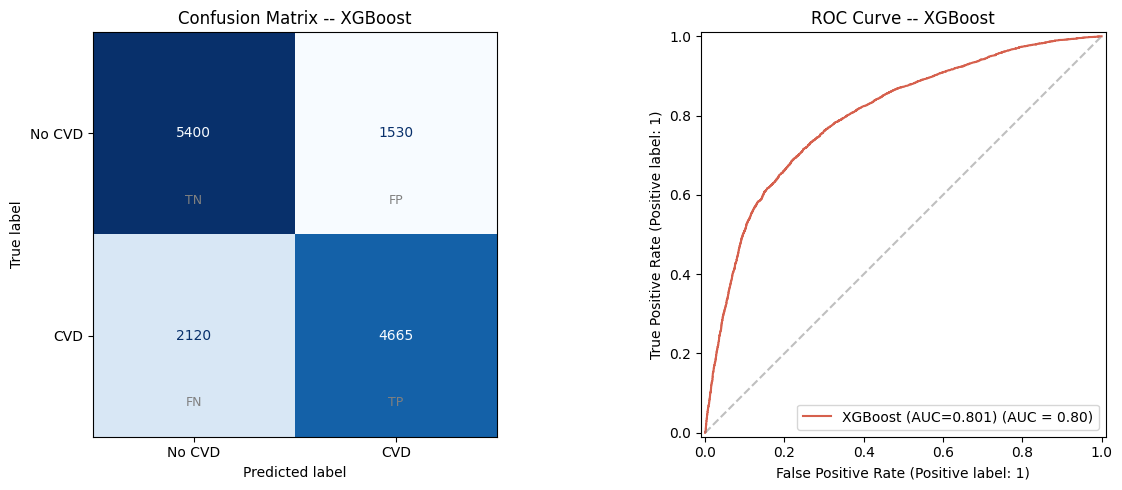


Classification Report (default 0.5 threshold):
              precision    recall  f1-score   support

      No CVD       0.72      0.78      0.75      6930
         CVD       0.75      0.69      0.72      6785

    accuracy                           0.73     13715
   macro avg       0.74      0.73      0.73     13715
weighted avg       0.74      0.73      0.73     13715



In [51]:
best_name  = df_res.index[0]
best_model = models[best_name]
best_uses_scaled = results[best_name]["uses_scaled"]
X_test_best = X_test_s if best_uses_scaled else X_test_sel
X_val_best  = X_val_s  if best_uses_scaled else X_val_sel
 
print(f"Best model by F1: {best_name}")
 
y_pred_best  = best_model.predict(X_test_best)
y_proba_best = best_model.predict_proba(X_test_best)[:, 1]
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
# -- Confusion Matrix --------------------------------------------------------
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["No CVD", "CVD"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Confusion Matrix -- {best_name}", fontsize=12)
 
for (j, i), val in np.ndenumerate(cm):
    lbl = {(0, 0): "TN", (0, 1): "FP", (1, 0): "FN", (1, 1): "TP"}[(j, i)]
    axes[0].text(i, j + 0.35, lbl, ha='center', fontsize=9, color='gray')
 
# -- ROC Curve ---------------------------------------------------------------
RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=axes[1],
                                  name=f"{best_name} (AUC={roc_auc_score(y_test, y_proba_best):.3f})",
                                  color="#D6604D")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)
axes[1].set_title(f"ROC Curve -- {best_name}", fontsize=12)
 
plt.tight_layout()
plt.show()
 
print("\nClassification Report (default 0.5 threshold):")
print(classification_report(y_test, y_pred_best, target_names=["No CVD", "CVD"]))

## 9. Threshold Tuning for Optimal Recall/Precision

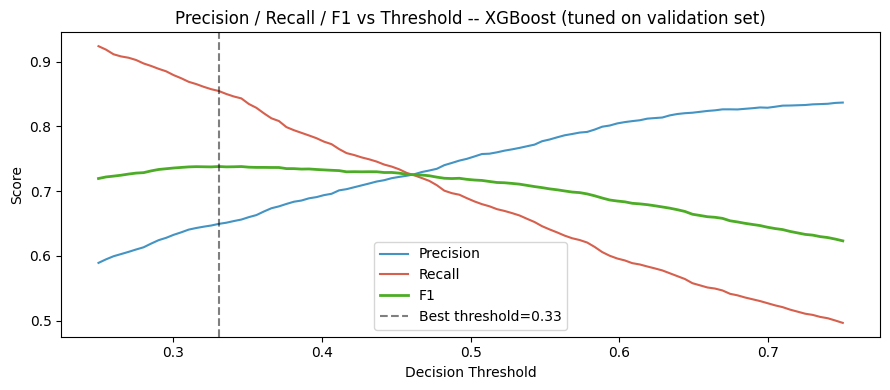

Best threshold (selected on validation set): 0.3308
Performance on TEST set at this threshold:
  Precision: 0.6453
  Recall   : 0.8567
  F1       : 0.7361


In [32]:
thresholds = np.linspace(0.25, 0.75, 100)
 
y_proba_val = best_model.predict_proba(X_val_best)[:, 1]
 
t_results = []
for t in thresholds:
    yp = (y_proba_val >= t).astype(int)
    t_results.append({
        "threshold": t,
        "precision": precision_score(y_val, yp, zero_division=0),
        "recall": recall_score(y_val, yp),
        "f1": f1_score(y_val, yp, zero_division=0)
    })
 
t_df = pd.DataFrame(t_results)
best_t = t_df.loc[t_df["f1"].idxmax(), "threshold"]
 
plt.figure(figsize=(9, 4))
plt.plot(t_df["threshold"], t_df["precision"], label="Precision", color="#4393C3")
plt.plot(t_df["threshold"], t_df["recall"], label="Recall", color="#D6604D")
plt.plot(t_df["threshold"], t_df["f1"], label="F1", color="#4DAC26", linewidth=2)
plt.axvline(best_t, color="black", linestyle="--", alpha=0.5,
            label=f"Best threshold={best_t:.2f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title(f"Precision / Recall / F1 vs Threshold -- {best_name} (tuned on validation set)")
plt.legend()
plt.tight_layout()
plt.show()
 
# Apply the validation-chosen threshold to the TEST set exactly once, for reporting.
y_tuned = (y_proba_best >= best_t).astype(int)
df_res.loc["XGBoost (Optimized)"] = {
    "Accuracy": accuracy_score(y_test, y_tuned),
    "Precision": precision_score(y_test, y_tuned),
    "Recall": recall_score(y_test, y_tuned),
    "F1": f1_score(y_test, y_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_proba_best),
    "CV-F1 mean": np.nan,
    "CV-F1 std": np.nan
}

print(f"Best threshold (selected on validation set): {best_t:.4f}")
print("Performance on TEST set at this threshold:")
print(f"  Precision: {precision_score(y_test, y_tuned):.4f}")
print(f"  Recall   : {recall_score(y_test, y_tuned):.4f}")
print(f"  F1       : {f1_score(y_test, y_tuned):.4f}")

## 10. SHAP Interpretability

Explains *why* the model predicts CVD for each patient — kept from original notebook and enhanced.

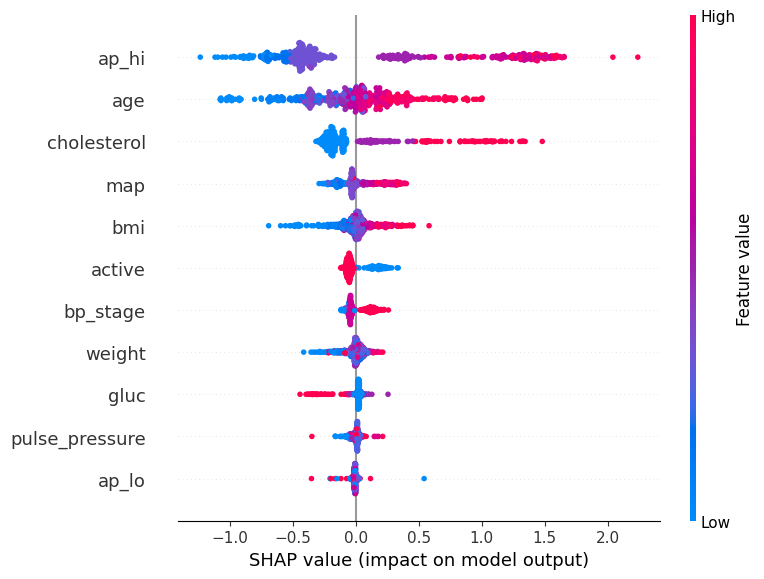

In [53]:
X_explain = X_test_best if not isinstance(X_test_best, np.ndarray) else pd.DataFrame(
    X_test_best, columns=selected_features
)
 
sample = X_explain.sample(n=min(500, len(X_explain)), random_state=42)
 
explainer = shap.Explainer(best_model, X_train_s if best_uses_scaled else X_train_sel)
shap_values = explainer(sample)
 
shap.summary_plot(shap_values, sample, show=True)

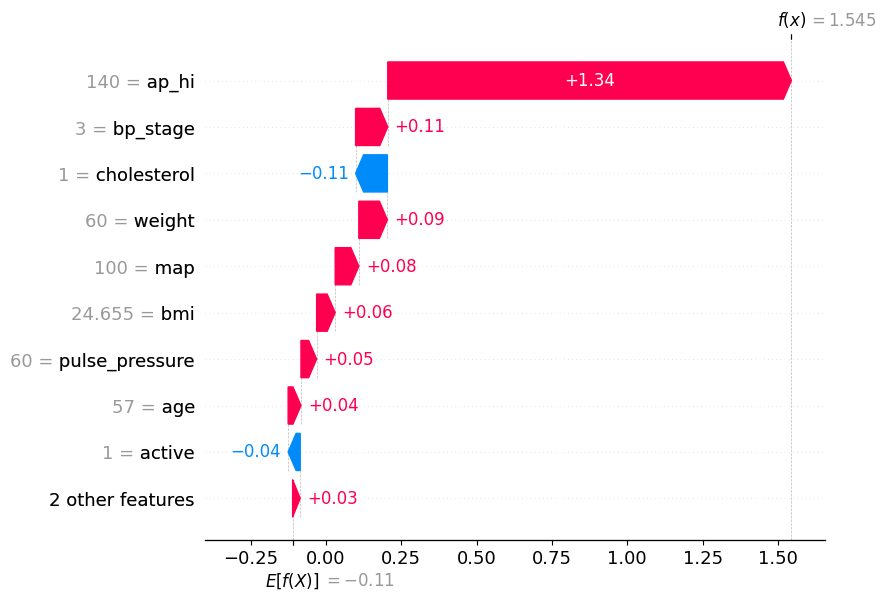

In [35]:
# Per-patient explanation for a single case (first row of the sample)
shap.plots.waterfall(shap_values[0], show=True)

## 11. Final Summary

In [47]:
 # ---------------------------------------------------------------- Final summary
print("=" * 70)
print("FINAL RESULTS SUMMARY".center(70))
print("=" * 70)
print(df_res[
        ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
    ])
 
print("\n" + "=" * 70)
print(f"BEST MODEL: {best_name}".center(70))
print(f"Tuned threshold (selected on validation set): {best_t:.4f}")
print(f"  Accuracy (test)  : {accuracy_score(y_test, y_tuned):.4f}")
print(f"  Precision (test) : {precision_score(y_test, y_tuned):.4f}")
print(f"  Recall (test)    : {recall_score(y_test, y_tuned):.4f}")
print(f"  F1 (test)        : {f1_score(y_test, y_tuned):.4f}")
print(f"  ROC-AUC (test)   : {roc_auc_score(y_test, y_proba_best):.4f}")

                        FINAL RESULTS SUMMARY                         
                     Accuracy Precision    Recall        F1   ROC-AUC
XGBoost                0.7339     0.753    0.6875    0.7188    0.8006
CatBoost               0.7327    0.7505    0.6886    0.7182     0.798
Logistic Regression    0.7293    0.7533    0.6735    0.7112    0.7937
Random Forest          0.7008    0.6979    0.6968    0.6973    0.7592
XGBoost (Optimized)  0.696172  0.645315  0.856743  0.736149  0.800612

                         BEST MODEL: XGBoost                          
Tuned threshold (selected on validation set): 0.3308
  Accuracy (test)  : 0.6962
  Precision (test) : 0.6453
  Recall (test)    : 0.8567
  F1 (test)        : 0.7361
  ROC-AUC (test)   : 0.8006


In [65]:
deployment_bundle = {
    "model": best_model,
    "model_name": best_name,
    "scaler": scaler if best_uses_scaled else None,
    "uses_scaled": best_uses_scaled,
    "selected_features": selected_features,   # exact column order the model expects
    "all_raw_features": list(X.columns),      # full engineered feature set, for reference
    "threshold": float(best_t),
    "metrics_test": {
        "accuracy": float(accuracy_score(y_test, y_tuned)),
        "precision": float(precision_score(y_test, y_tuned)),
        "recall": float(recall_score(y_test, y_tuned)),
        "f1": float(f1_score(y_test, y_tuned)),
        "roc_auc": float(roc_auc_score(y_test, y_proba_best)),
    },
    "sklearn_version": sklearn.__version__,
    "xgboost_version": xgboost.__version__,
    "catboost_version": catboost.__version__,
    "python_version": platform.python_version(),
}

os.makedirs("models", exist_ok=True)
joblib.dump(deployment_bundle, "models/cvd_model_bundle.joblib")
print("Saved cvd_model_bundle.joblib")
print(json.dumps({k: v for k, v in deployment_bundle.items()
                   if k not in ("model", "scaler")}, indent=2))

Saved cvd_model_bundle.joblib
{
  "model_name": "XGBoost",
  "uses_scaled": false,
  "selected_features": [
    "ap_hi",
    "map",
    "bp_stage",
    "ap_lo",
    "pulse_pressure",
    "age",
    "cholesterol",
    "bmi",
    "weight",
    "gluc",
    "active"
  ],
  "all_raw_features": [
    "age",
    "gender",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cholesterol",
    "gluc",
    "smoke",
    "alco",
    "active",
    "bmi",
    "pulse_pressure",
    "map",
    "bp_stage"
  ],
  "threshold": 0.33080808080808083,
  "metrics_test": {
    "accuracy": 0.6961720743711265,
    "precision": 0.6453152753108348,
    "recall": 0.8567428150331614,
    "f1": 0.7361489267396948,
    "roc_auc": 0.8006117603022541
  },
  "sklearn_version": "1.7.2",
  "xgboost_version": "2.0.3",
  "catboost_version": "1.2.10",
  "python_version": "3.10.16"
}
